# 01 - plot_plume_path_sum\n
Derived from `notebooks/prior_versions/plume_path_plot_clean.ipynb`.\n

In [114]:
import platform
import socket
import sys
from pathlib import Path

src_dir = next(p / "src" for p in (Path.cwd(), *Path.cwd().parents) if (p / "src" / "polarcap_runtime.py").is_file())
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from polarcap_runtime import is_server

print("system:", platform.system(), platform.release())
print("hostname:", socket.gethostname())
print("is_server:", is_server())

system: Darwin 25.3.0
hostname: 22182-mbp-2.fritz.box
is_server: False


In [115]:
from __future__ import annotations

import re, sys
from pathlib import Path
import colormaps as pcmaps
import matplotlib.axes as maxes
import matplotlib.dates as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.colors import LogNorm, ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FixedLocator, LogLocator, FuncFormatter

xr.set_options(keep_attrs=True)

sys.path.insert(0, str((Path.cwd() / ".." / "src").resolve()))
from utilities import make_pastel, load_plume_path_runs, format_elapsed_minutes_tick, create_fade_cmap
from utilities.holimo_helpers import load_and_prepare_holimo

def create_new_jet3(n_colors=256, n_ice_colors=32):
    ice_colors = pcmaps.ice(np.linspace(1, 0.5, n_ice_colors))
    bk_colors  = pcmaps.BkBlAqGrYeOrReViWh200(np.linspace(0.1, 0.9, n_colors))
    transition = np.linspace(ice_colors[-1], bk_colors[0], 16)[1:-1]
    return ListedColormap(np.vstack([ice_colors, transition, bk_colors]))

new_jet4 = create_new_jet3(1024)

new_jet3 = create_new_jet3()
new_jet3_soft = create_fade_cmap(make_pastel(new_jet3, desaturation=0.25, darken=0.90), n_fade=2)


In [116]:
def format_axis_ticks(
    self,
    *,
    y_tick_pos: str = "both",
    x_tick_pos: str = "bottom",
    y_tick_labels: bool = False,
    x_tick_labels: bool = False,
    y_label: str = "",
    x_label: str = "",
    grid: bool = True,
):
    self.tick_params(which="both", direction="out", top=True, right=True, bottom=True, left=True)
    self.minorticks_on()
    self.tick_params(which="major", direction="out", length=7, width=0.9)
    self.tick_params(which="minor", direction="out", length=5, width=0.5)
    self.set_xlabel(x_label)
    self.set_ylabel(y_label)
    self.yaxis.set_ticks_position(y_tick_pos)
    self.xaxis.set_ticks_position(x_tick_pos)
    if not y_tick_labels:
        self.yaxis.set_ticklabels([])
    else:
        self.yaxis.set_major_formatter(plt.FuncFormatter(
            lambda x, p: f'{x:.3f}'.rstrip('0').rstrip('.') if x < 1 else f'{x:.0f}'))
    if not x_tick_labels:
        self.xaxis.set_ticklabels([])
    if grid:
        self.grid(True, which="major", linestyle="--", linewidth=0.25, color="black", alpha=0.6)
        self.grid(True, which="minor", linestyle=":", linewidth=0.15, color="black", alpha=0.35)
    self.set_axisbelow(False)


def format_elapsed_time(
    self,
    t0,
    t_end,
    *,
    major_interval: int = 5,
    minor_interval: int = 1,
    max_major_ticks: int = 14,
    max_minor_ticks: int = 180,
):
    """Format elapsed-time axis in minutes (numeric x axis)."""
    duration_min = float((t_end - t0) / np.timedelta64(1, "m"))
    if not np.isfinite(duration_min) or duration_min <= 0:
        return

    major_step = max(int(major_interval), int(np.ceil(duration_min / max_major_ticks)))
    minor_step = max(int(minor_interval), int(np.ceil(duration_min / max_minor_ticks)))

    major_times = np.arange(0, duration_min + major_step, major_step)
    minor_times = np.arange(0, duration_min + minor_step, minor_step)

    self.xaxis.set_major_locator(FixedLocator(major_times))
    self.xaxis.set_minor_locator(FixedLocator(minor_times))
    self.set_xticklabels([f"+{int(t):02d}" for t in major_times])


def add_missing_data_patches(
    self,
    da: xr.DataArray,
    *,
    min_consecutive: int = 2,
    add_legend: bool = True,
    y_extend=(1, 1000),
    **patch_kw,
):
    if "time" not in da.dims:
        return

    if "diameter" in da.dims:
        dvals = da["diameter"].values
        y0, y1 = dvals[0] - y_extend[0], dvals[-1] + y_extend[1]
    else:
        y0, y1 = y_extend

    collapse_dims = [d for d in da.dims if d not in {"time", "diameter"}]
    d1 = da.sum(dim=collapse_dims) if collapse_dims else da
    mask = ~(d1.sum(dim="diameter") > 0) if "diameter" in d1.dims else ~(d1 > 0)
    mask = np.asarray(mask).ravel()
    if not mask.any():
        return

    ti = np.where(mask)[0]
    split = np.where(np.diff(ti) > 1)[0] + 1
    starts = np.r_[0, split]
    ends = np.r_[split, len(ti)]
    tvals = d1["time"].values

    opts = {
        "facecolor": "lightgray",
        "edgecolor": "black",
        "alpha": 0.2,
        "linewidth": 0.2,
        "hatch": "///",
        "zorder": 1,
        **patch_kw,
    }
    for s, e in zip(starts, ends):
        if e - s < min_consecutive:
            continue
        t0, t1 = tvals[ti[s]], tvals[ti[e - 1]]
        x0, x1 = md.date2num(t0), md.date2num(t1)
        self.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, **opts))


maxes.Axes.format_axis_ticks = format_axis_ticks
maxes.Axes.format_elapsed_time = format_elapsed_time
maxes.Axes.add_missing_data_patches = add_missing_data_patches


In [117]:
def _prepare_da(ds: xr.Dataset, variable: str, *, sum_cell: bool = True) -> xr.DataArray:
    """Fetch a plotting variable and optionally collapse cell dimension."""
    if variable not in ds:
        raise KeyError(f"Variable '{variable}' missing. Available: {list(ds.data_vars)}")
    da = ds[variable]
    if sum_cell and "cell" in da.dims:
        da = da.sum("cell", keep_attrs=True, skipna=True)
    # if zlim is not None and "altitude" in da.coords:
    #     z0, z1 = zlim
    #     da = da.where((da.altitude >= z0) & (da.altitude <= z1), drop=True)
    return da


def _assign_elapsed_time(da: xr.DataArray, t0: np.datetime64) -> xr.DataArray:
    """Attach elapsed time in minutes as `time_elapsed` coordinate."""
    mins = (da.time - t0) / np.timedelta64(1, "m")
    return da.assign_coords(time_elapsed=("time", mins.values))


def build_common_xlim(
    ds_by_run: dict[str, dict[str, xr.Dataset]],
    *,
    kind: str = "integrated",
    span_min: int = 5,
    anchor: np.datetime64 | None = None,
) -> list[np.datetime64]:
    """Build a common absolute time window for all runs."""
    starts = []
    for run in ds_by_run.values():
        ds = run.get(kind)
        if not isinstance(ds, xr.Dataset):
            continue
        if "time" not in ds.coords or ds.time.size == 0:
            continue
        starts.append(np.datetime64(ds.time.values.min(), "s"))

    if not starts:
        raise ValueError(f"Cannot infer xlim: no datasets with kind='{kind}' and valid time")

    if anchor is None:
        # Domain-specific default: start one minute before flare ignition.
        day = str(min(starts))[:10]
        t0 = np.datetime64(f"{day}T12:29:00")
    else:
        t0 = np.datetime64(anchor, "s")

    return [t0, t0 + np.timedelta64(int(span_min), "m")]


def _plume_path_intervals(xl: list[np.datetime64] | None) -> tuple[int, int]:
    """Choose major/minor elapsed-time tick intervals from time-span."""
    if xl:
        dt = np.diff(xl)[0]
        if dt < np.timedelta64(5, "m"):
            return 1, 30
        if dt < np.timedelta64(30, "m"):
            return 5, 10
        if dt < np.timedelta64(60, "m"):
            return 5, 30
        return 30, 10
    return 15, 1


def _plume_path_major_locs_from_span(span: float) -> np.ndarray:
    """Return canonical major tick locations for elapsed-time axes."""
    if span <= 10:
        return np.array([0.1, 1, 2, 5, 10])
    if span <= 60:
        return np.array([0.1, 1, 2, 5, 10, 20, 45, 60])
    return np.array([0.1, 1, 5, 10, 30, 60, 120])


def _plume_path_log_axis_params(xl: list[np.datetime64]) -> tuple[np.datetime64, float, float, float, np.ndarray]:
    """Build log-axis numeric bounds and major tick locations."""
    t0 = xl[0]
    x_min = float((xl[0] - t0) / np.timedelta64(1, "m"))
    x_max = float((xl[1] - t0) / np.timedelta64(1, "m"))
    if x_min <= 0:
        x_min = 0.1
    span = x_max - x_min
    major_locs = _plume_path_major_locs_from_span(span)
    return t0, x_min, x_max, span, major_locs


def compute_holimo_elapsed_anchors(
    ds_hd10: xr.Dataset,
    obs_ids: list[str],
    time_frames_plume: list[list[np.datetime64]],
    growth_times_min: list[float] | None = None,
    seeding_start_times: list[np.datetime64] | None = None,
    var_candidates: list[str] | None = None,
) -> dict[str, float]:
    """Compute mission-specific HOLIMO elapsed-time anchors in minutes."""
    if var_candidates is None:
        var_candidates = sorted([v for v in ds_hd10.data_vars if v.startswith("Ice_") and v.endswith("PSDlogNorm")])

    anchors = {}
    for i, (obs_id, (t_lo, t_hi)) in enumerate(zip(obs_ids, time_frames_plume)):
        ds_ = ds_hd10.sel(time=slice(t_lo, t_hi))
        if ds_.time.size == 0:
            anchors[obs_id] = np.nan
            continue

        # Preferred: elapsed time is referenced to mission seeding start.
        if seeding_start_times is not None and i < len(seeding_start_times):
            seed_t = np.datetime64(seeding_start_times[i])
            anchors[obs_id] = float((np.datetime64(ds_.time.values[0]) - seed_t) / np.timedelta64(1, "m"))
            continue

        # Fallback: infer anchor from first non-zero signal + growth time.
        first_idx = None
        for var in var_candidates:
            if var not in ds_.data_vars:
                continue
            arr = np.asarray(ds_[var].values)
            nz = np.isfinite(arr) & (arr > 0)
            if not nz.any():
                continue
            time_hit = int(np.argmax(nz.any(axis=tuple(range(1, arr.ndim)))))
            first_idx = time_hit if first_idx is None else min(first_idx, time_hit)

        if first_idx is None:
            anchors[obs_id] = np.nan
            continue

        dt_min = float((ds_.time[1] - ds_.time[0]).values / np.timedelta64(1, "m")) if ds_.time.size > 1 else 0.0
        growth_min = float(growth_times_min[i]) if growth_times_min is not None and i < len(growth_times_min) else 0.0
        anchors[obs_id] = growth_min + first_idx * dt_min

    return anchors


def diagnostics_table(
    ds_by_run: dict[str, dict[str, xr.Dataset]],
    *,
    kind: str = "integrated",
    variable: str = "nf",
    xlim: list[np.datetime64] | None = None,
) -> pd.DataFrame:
    """Summarize data availability and finite coverage per run."""
    rows = []
    for label, run in ds_by_run.items():
        ds = run.get(kind)
        if ds is None:
            rows.append({"run": label, "status": "missing kind"})
            continue
        if not isinstance(ds, xr.Dataset):
            rows.append({"run": label, "status": f"invalid kind type: {type(ds).__name__}"})
            continue

        row = {
            "run": label,
            "status": "ok",
            "n_cells": int(ds.sizes.get("cell", 1)),
            "n_time": int(ds.sizes.get("time", 0)),
            "time_min": str(ds.time.values.min()).split(".")[0] if "time" in ds.coords and ds.time.size else "-",
            "time_max": str(ds.time.values.max()).split(".")[0] if "time" in ds.coords and ds.time.size else "-",
            "has_var": variable in ds,
        }

        if variable in ds and "time" in ds[variable].dims and xlim is not None:
            in_win = ds[variable].sel(time=slice(xlim[0], xlim[1]))
            row["n_time_in_xlim"] = int(in_win.sizes.get("time", 0))
            row["finite_in_xlim"] = int(np.isfinite(in_win.values).sum())
        rows.append(row)

    return pd.DataFrame(rows)


def _plume_path_annotate_letters(axes: np.ndarray | list) -> None:
    """Annotate subplot panels with letters (A), (B), ..."""
    for i, ax in enumerate(np.atleast_1d(axes).flatten()):
        ax.text(0.02, 0.98, f'({chr(65+i)})', transform=ax.transAxes, ha='left', va='top', fontweight='semibold', fontsize=14)


def plot_plume_path_sum(
    ds_by_run: dict[str, dict[str, xr.Dataset]],
    *,
    # Returns (fig, axes) or (fig, axes, pmesh) when return_pmesh=True.
    kind: str = "integrated",
    variable: str = "nf",
    xlim=None,
    common_xlim_minutes: int | None = 35,
    ylim=(1, 2000),
    zlim=None,
    cmap="viridis",
    log_norm=True,
    x_axis_fmt: str = "elapsed",  # 'datetime', 'elapsed', 'log', 'symlog'
    add_missing_data=True,
    figsize_scale=(6.5, 3.6),
    annote_letters=True,
    holimo_overlay: dict | None = None,
    symlog_shift_start_idx: int = 0,
    symlog_panel_shift_min: float = 1.0,
    axes_override: np.ndarray | list | None = None,
    add_colorbar: bool = True,
    add_shared_labels: bool = True,
    marker_size_scale: float = 1.0,
    return_pmesh: bool = False,
    cbar_kwargs: dict | None = None,
    add_holimo_legend: bool = True,
):
    labels = [k for k, v in ds_by_run.items() if isinstance(v.get(kind), xr.Dataset)]
    if not labels:
        raise ValueError(f"No datasets available for kind='{kind}'")

    if x_axis_fmt in {"elapsed", "log", "symlog"} and xlim is None and common_xlim_minutes is not None:
        xlim = build_common_xlim(ds_by_run, kind=kind, span_min=common_xlim_minutes)

    n = len(labels)
    ncols = 3 if n > 1 else 1
    nrows = int(np.ceil(n / ncols))

    if axes_override is None:
        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(figsize_scale[0] * ncols, figsize_scale[1] * nrows),
            constrained_layout=True,
            squeeze=False,
            sharex=True,
            sharey=True,
        )
        axes = axes.ravel()
    else:
        axes = np.atleast_1d(axes_override).ravel()
        if len(axes) < n:
            raise ValueError(f"axes_override has {len(axes)} axes but {n} panels are required")
        fig = axes[0].figure

    pmesh = None
    panel_fill = []
    obs_legend_added = False
    xlabel = "elapsed time / (min)" if x_axis_fmt in {"elapsed", "log", "symlog"} else "time"
    cbar_kwargs = cbar_kwargs or {}
    cbar_kwargs["shrink"] = cbar_kwargs.get("shrink", 0.75)
    cbar_kwargs["aspect"] = cbar_kwargs.get("aspect", 40)
    cbar_kwargs["pad"] = cbar_kwargs.get("pad", 0.005)
    cbar_kwargs["label"] = cbar_kwargs.get("label", " ")
    cbar_kwargs["extend"] = cbar_kwargs.get("extend", "both")
    
    obs_cfg = None
    if holimo_overlay is not None:
        obs_cfg = {
            "ds": holimo_overlay["ds_hd10"],
            "var": holimo_overlay.get("var", "Ice_PSDlogNorm"),
            "obs_ids": holimo_overlay["obs_ids"],
            "frames": holimo_overlay["time_frames_plume"],
            "growth": holimo_overlay.get("growth_times_min"),
            "seed_starts": holimo_overlay.get("seeding_start_times"),
            "threshold": holimo_overlay.get("threshold", 1.e-10),
            "unit_factor": holimo_overlay.get("unit_factor", 1.0),
            "scatter_cmap": holimo_overlay.get("scatter_cmap", cmap),
            "markers": holimo_overlay.get("markers", ["o", "s", "^"]),
            "sizes": holimo_overlay.get("sizes", np.array([16, 18, 20])*marker_size_scale),
            "alpha": holimo_overlay.get("alpha", 0.9),
            "edgecolor": holimo_overlay.get("edgecolor", "black"),
            "linewidth": holimo_overlay.get("linewidth", 0.35),
            "legend_loc": holimo_overlay.get("legend_loc", "upper right"),
            
        }
        obs_cfg["anchors"] = holimo_overlay.get(
            "anchor_map",
            compute_holimo_elapsed_anchors(
                obs_cfg["ds"],
                obs_cfg["obs_ids"],
                obs_cfg["frames"],
                growth_times_min=obs_cfg["growth"],
                seeding_start_times=obs_cfg["seed_starts"],
            ),
        )

    for i, label in enumerate(labels):
        ax = axes[i]
        ds = ds_by_run[label].get(kind)
        if not isinstance(ds, xr.Dataset):
            ax.text(0.5, 0.5, f"Invalid data type for kind='{kind}'\n{label}", ha="center", va="center", transform=ax.transAxes)
            panel_fill.append(1.0)
            continue
        da = _prepare_da(ds, variable, sum_cell=True)

        if xlim is not None:
            da = da.sel(time=slice(xlim[0], xlim[1]))
        if da.sizes.get("time", 0) == 0:
            ax.text(0.5, 0.5, f"No data\n{label}", ha="center", va="center", transform=ax.transAxes)
            continue

        coord = "time"
        elapsed_shift = 0.0
        panel_shift = symlog_panel_shift_min if (x_axis_fmt == "symlog" and i >= symlog_shift_start_idx) else 0.0
        if x_axis_fmt in {"elapsed", "log", "symlog"}:
            t0 = xlim[0] if xlim is not None else da.time.min().values
            da = _assign_elapsed_time(da, t0)

            if x_axis_fmt == "log":
                da = da.assign_coords(time_elapsed=("time", np.where(da.time_elapsed.values <= 0, 0.1, da.time_elapsed.values)))

            if x_axis_fmt == "symlog":
                # Shift first valid plume signal to x=0.1 while preserving x=0 ignition marker.
                collapse_dims = [d for d in da.dims if d != "time"]
                valid = da.sum(dim=collapse_dims, skipna=True) > 0 if collapse_dims else da > 0
                valid_times = da.time_elapsed.where(valid, drop=True)
                if valid_times.size:
                    first_valid = float(valid_times.min().values)
                    max_shift_min = 10.0 / 60.0
                    if 0.1 < first_valid <= (0.1 + max_shift_min):
                        elapsed_shift = first_valid - 0.1
                        shifted = da.time_elapsed.values - elapsed_shift
                        da = da.assign_coords(time_elapsed=("time", np.where(shifted < 0, 0.0, shifted)))
                if panel_shift > 0:
                    da = da.assign_coords(time_elapsed=("time", np.where(da.time_elapsed.values - panel_shift < 0, 0.0, da.time_elapsed.values - panel_shift)))

            coord = "time_elapsed"

        vlim_kw = {}
        if zlim is not None:
            vmin, vmax = zlim
        else:
            positive = da.where(da > 0)
            vmin = float(positive.min(skipna=True))
            vmax = float(positive.max(skipna=True))

        if log_norm:
            if vmin and vmax and vmax > vmin:
                vlim_kw["norm"] = LogNorm(vmin=vmin, vmax=vmax)
            else:
                vlim_kw["vmin"] = vmin
                vlim_kw["vmax"] = vmax

        pmesh = da.plot(x=coord, y="diameter", ax=ax, cmap=cmap, add_colorbar=False, **vlim_kw)
        model_norm = vlim_kw.get("norm", plt.Normalize(vmin=vmin, vmax=vmax))
        panel_fill.append(float(np.isfinite(da.values).sum()) / float(np.prod(da.shape)))

        if add_missing_data:
            ax.add_missing_data_patches(da, min_consecutive=1, add_legend=False)
        ax.set_title(label, fontsize=10)
        ax.set_ylim(*ylim)
        ax.set_yscale("log")
        ax.format_axis_ticks(y_tick_pos="left", y_tick_labels=True, x_tick_labels=True, grid=True)

        if x_axis_fmt == "elapsed":
            if xlim is not None:
                duration_min = float((xlim[1] - xlim[0]) / np.timedelta64(1, "m"))
                ax.set_xlim(0, duration_min)
                mi, Mi = _plume_path_intervals(xlim)
                ax.format_elapsed_time(xlim[0], xlim[1], major_interval=mi, minor_interval=Mi)
        elif x_axis_fmt == "log":
            if xlim is not None:
                t0, x_min, x_max, span, major_locs = _plume_path_log_axis_params(xlim)
            else:
                t0 = da.time.values.min()
                t1 = da.time.values.max()
                t0, x_min, x_max, span, major_locs = _plume_path_log_axis_params([t0, t1])
            ax.set_xscale("log")
            ax.set_xlim(x_min, x_max)
            ax.xaxis.set_major_locator(FixedLocator([v for v in major_locs if x_min <= v <= x_max]))
            ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=range(1, 10)))
            tick_fmt = lambda x, p: format_elapsed_minutes_tick(x, span)
            ax.xaxis.set_major_formatter(FuncFormatter(tick_fmt))
        elif x_axis_fmt == "symlog":
            if xlim is not None:
                x_max = float((xlim[1] - xlim[0]) / np.timedelta64(1, "m"))
            else:
                x_max = float(np.nanmax(da.time_elapsed.values))
            x_max = max(x_max, 0.1)
            span = x_max - 0.1
            major_locs = _plume_path_major_locs_from_span(span)
            ticks = np.array([0.0] + [v for v in major_locs if v <= x_max])

            ax.set_xscale("symlog", linthresh=0.1, linscale=0.001)
            ax.set_xlim(0, x_max)
            ax.xaxis.set_major_locator(FixedLocator(ticks))
            ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=range(1, 10)))
            tick_fmt = lambda x, p: format_elapsed_minutes_tick(x, span, zero_if_close=True)
            ax.xaxis.set_major_formatter(FuncFormatter(tick_fmt))
        elif xlim is not None:
            ax.set_xlim(*xlim)

        if obs_cfg is not None and x_axis_fmt in {"elapsed", "log", "symlog"}:
            if obs_cfg["var"] not in obs_cfg["ds"].data_vars:
                continue

            for i_obs, (obs_id, (t_lo, t_hi)) in enumerate(zip(obs_cfg["obs_ids"], obs_cfg["frames"])):
                anchor = obs_cfg["anchors"].get(obs_id, np.nan)
                if not np.isfinite(anchor):
                    continue

                da_obs = obs_cfg["ds"][obs_cfg["var"]].sel(time=slice(t_lo, t_hi))
                if da_obs.time.size == 0 or "diameter" not in da_obs.dims:
                    continue

                dt_min = (da_obs.time - da_obs.time[0]).values / np.timedelta64(1, "m")
                elapsed = anchor + dt_min
                if x_axis_fmt == "log":
                    elapsed = np.where(elapsed <= 0, 0.1, elapsed)
                elif x_axis_fmt == "symlog":
                    elapsed = np.where(elapsed - elapsed_shift - panel_shift < 0, 0.0, elapsed - elapsed_shift - panel_shift)

                da_obs = da_obs.assign_coords(time_elapsed=("time", elapsed))
                da_obs = xr.where(da_obs > obs_cfg["threshold"], da_obs, np.nan) * obs_cfg["unit_factor"]
                da_obs = da_obs.transpose("time", "diameter")

                vals = np.asarray(da_obs.values, dtype=float)
                diam = np.asarray(da_obs["diameter"].values, dtype=float)
                xvals = np.asarray(da_obs.time_elapsed.values, dtype=float)
                w = np.where(np.isfinite(vals) & (vals > 0), vals, np.nan)
                denom = np.nansum(w, axis=1)
                ok = np.isfinite(denom) & (denom > 0)
                if not ok.any():
                    continue

                mean_d = np.full_like(denom, np.nan, dtype=float)
                mean_d[ok] = np.nansum(w[ok] * diam[None, :], axis=1) / denom[ok]

                # Color each dot by HOLIMO concentration at the plotted mean diameter.
                cvals = np.full_like(mean_d, np.nan, dtype=float)
                for it in np.where(ok)[0]:
                    row = vals[it]
                    finite = np.isfinite(row)
                    if finite.sum() < 2:
                        continue
                    cvals[it] = np.interp(mean_d[it], diam[finite], row[finite], left=np.nan, right=np.nan)

                mk = obs_cfg["markers"][i_obs % len(obs_cfg["markers"])]
                size = obs_cfg["sizes"][i_obs % len(obs_cfg["sizes"])]
                valid_scatter = np.isfinite(xvals) & np.isfinite(mean_d) & np.isfinite(cvals)
                if isinstance(model_norm, LogNorm):
                    valid_scatter &= cvals > 0
                if not valid_scatter.any():
                    continue
                ax.scatter(
                    xvals[valid_scatter],
                    mean_d[valid_scatter],
                    c=cvals[valid_scatter],
                    cmap=obs_cfg["scatter_cmap"],
                    marker=mk,
                    s=size,
                    alpha=obs_cfg["alpha"],
                    edgecolors=obs_cfg["edgecolor"],
                    linewidths=obs_cfg["linewidth"],
                    zorder=126,
                    label=obs_id,
                    **vlim_kw,
                )

            if add_holimo_legend and not obs_legend_added and ax.collections:
                handles = []
                for j, obs_id in enumerate(obs_cfg["obs_ids"]):
                    mk = obs_cfg["markers"][j % len(obs_cfg["markers"])]
                    handles.append(
                        Line2D(
                            [0], [0],
                            marker=mk,
                            linestyle="None",
                            markerfacecolor="grey",
                            markeredgecolor="black",
                            markeredgewidth=0.4,
                            markersize=5,
                            alpha=0.8,
                            label=obs_id,
                        )
                    )
                ax.legend(handles=handles, title="HOLIMO missions", fontsize=7, title_fontsize=7, loc=obs_cfg["legend_loc"], framealpha=0.8)
                obs_legend_added = True

        # Re-apply axis mode after HOLIMO overlay (xarray plotting may reset axis state).
        if x_axis_fmt == "elapsed":
            if xlim is not None:
                duration_min = float((xlim[1] - xlim[0]) / np.timedelta64(1, "m"))
                ax.set_xlim(0, duration_min)
                mi, Mi = _plume_path_intervals(xlim)
                ax.format_elapsed_time(xlim[0], xlim[1], major_interval=mi, minor_interval=Mi)
            ax.set_xlabel("")
        elif x_axis_fmt == "log":
            if xlim is not None:
                _, x_min, x_max, span, major_locs = _plume_path_log_axis_params(xlim)
            else:
                x_min = 0.1
                x_max = float(np.nanmax(da.time_elapsed.values)) if "time_elapsed" in da.coords else 1.0
                span = x_max - x_min
                major_locs = _plume_path_major_locs_from_span(span)
            ax.set_xscale("log")
            ax.set_xlim(x_min, x_max)
            ax.xaxis.set_major_locator(FixedLocator([v for v in major_locs if x_min <= v <= x_max]))
            ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=range(1, 10)))
            tick_fmt = lambda x, p: format_elapsed_minutes_tick(x, span)
            ax.xaxis.set_major_formatter(FuncFormatter(tick_fmt))
            ax.set_xlabel("")
        elif x_axis_fmt == "symlog":
            if xlim is not None:
                x_max = float((xlim[1] - xlim[0]) / np.timedelta64(1, "m"))
            else:
                x_max = float(np.nanmax(da.time_elapsed.values)) if "time_elapsed" in da.coords else 1.0
            x_max = max(x_max, 0.1)
            span = x_max - 0.1
            major_locs = _plume_path_major_locs_from_span(span)
            ticks = np.array([0.0] + [v for v in major_locs if v <= x_max])
            ax.set_xscale("symlog", linthresh=0.1, linscale=0.01)
            ax.set_xlim(0, x_max)
            ax.xaxis.set_major_locator(FixedLocator(ticks))
            ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=range(1, 10)))
            tick_fmt = lambda x, p: format_elapsed_minutes_tick(x, span, zero_if_close=True)
            ax.xaxis.set_major_formatter(FuncFormatter(tick_fmt))
            ax.set_xlabel("")
        elif xlim is not None:
            ax.set_xlim(*xlim)

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    if add_colorbar and pmesh is not None:
        unit = da.attrs.get("units", "-")
        cbar_kwargs["label"] = cbar_kwargs.get("label", rf"{kind} {variable} per bin / ({unit})")
        fig.colorbar(pmesh, ax=axes[0], **cbar_kwargs)

    if annote_letters:
        _plume_path_annotate_letters(axes[:n])

    if add_shared_labels:
        fig.supylabel("equivalent diameter / (µm)")
        fig.supxlabel(xlabel)

    if return_pmesh:
        return fig, axes[:n], pmesh
    return fig, axes[:n]


In [118]:
# ---- user config ----
PROCESSED_ROOT = Path("../../data/processed")
RUNS = [
    # active in figure1
    {"label": "400m, inp 1e6, ccn 0 (run A)", "cs_run": "cs-eriswil__20251129_230943", "exp_id": "20251129231107"},
    # {"label": "400m, inp 1e6, ccn 0 (run B)", "cs_run": "cs-eriswil__20251129_230943", "exp_id": "20260119103733"},

    # previously commented in figure1 (now included)
    # {"label": "400m, inp 1e6, ccn 400 (columnar)", "cs_run": "cs-eriswil__20251125_114053", "exp_id": "20260120122711"},
    # {"label": "400m, inp 1e6, ccn 0 (spherical)", "cs_run": "cs-eriswil__20251125_114053", "exp_id": "20251125114238"},
    # {"label": "400m, inp 1e6, ccn 400 (analytic)", "cs_run": "cs-eriswil__20260127_211338", "exp_id": "20260127211431"},
    # {"label": "400m, inp 1e6, ccn 400 (planar)", "cs_run": "cs-eriswil__20260127_211338", "exp_id": "20260127211551"},
    # {"label": "400m, inp 1e6, ccn 400 (spherical)", "cs_run": "cs-eriswil__20260121_131528", "exp_id": "20260121131550"},
    # {"label": "400m, inp 1e6, ccn 400 (columnar 2)", "cs_run": "cs-eriswil__20260121_131528", "exp_id": "20260121131632"},
    # {"label": "100m, inp 1e6, ccn 0 (columnar)", "cs_run": "cs-eriswil__20260123_180947", "exp_id": "20260123181336"},
    # {"label": "100m, inp 1e6, ccn 400 (columnar)", "cs_run": "cs-eriswil__20260123_180947", "exp_id": "20260123181750"},
    # {"label": "100m, inp 1e6, ccn 400 (spherical, same exp)", "cs_run": "cs-eriswil__20260123_180947", "exp_id": "20260123181750"},
]

KINDS = ("integrated",)

datasets = load_plume_path_runs(
    RUNS,
    processed_root=PROCESSED_ROOT,
    kinds=KINDS,
)

try:
    xlim = build_common_xlim(datasets, kind="integrated", span_min=35)
except ValueError:
    # Fallback window if no valid times are discoverable in current environment.
    xlim = [np.datetime64("2023-01-25T12:29:00"), np.datetime64("2023-01-25T13:04:00")]

diag = diagnostics_table(datasets, kind="integrated", variable="nf", xlim=xlim)
print(diag.to_string(index=False))





                         run status  n_cells  n_time            time_min            time_max  has_var  n_time_in_xlim  finite_in_xlim
400m, inp 1e6, ccn 0 (run A)     ok        6     251 2023-01-25T12:23:20 2023-01-25T13:05:00     True             211           14580


# HOLIMO DATA


TBD: check how much smoothing of the Holimo data is needed to do a comparison with the model data. Holimos observationsal volume is in order of a couple of centimeters compared to the model which is of horizontal resolution of >400m (or >100m depending on the run).


In [119]:

holimo_file      = '../../data/observations/holimo_data/CL_20230125_1000_1140_SM058_SM060_ts1.nc'

time_window_holimo = (np.datetime64('2023-01-25T10:10:00'), np.datetime64('2023-01-25T12:00:00'))
time_frames_plume = [   
    [ np.datetime64('2023-01-25T10:55:00'), np.datetime64('2023-01-25T11:10:00')   ],
    [ np.datetime64('2023-01-25T10:35:00'), np.datetime64('2023-01-25T10:50:00')   ],
    [ np.datetime64('2023-01-25T11:24:00'), np.datetime64('2023-01-25T11:39:00')   ],
    ]

obs_ids = [
    "SM059", 
    "SM058", 
    "SM060"
    ]
growth_times_min = [
    6.1, 
    8.0, 
    9.1,
    ]
seeding_start_times = [
    np.datetime64('2023-01-25T10:50:00'),
    np.datetime64('2023-01-25T10:28:00'),
    np.datetime64('2023-01-25T11:15:00'),
]


ds_holimo, lbb, cbb = load_and_prepare_holimo(holimo_file)
ds_holimo = ds_holimo.sel(time=slice(*time_window_holimo))
ds_holimo = ds_holimo.assign_coords({'diameter': ds_holimo.diameter * 1e6})

# Gap-aware processing for paper figures:
# 1) resample to a regular 10 s grid,
# 2) remove bins with too little temporal coverage,
# 3) apply a centered 30 s rectangular (boxcar) smoothing.
# This avoids uneven effective windows when the raw observations have gaps.
holimo_expected_dt_s = 1
holimo_resample_s = 10
smoothing_time_bins = 8
smoothing_diameter_bins = 0
holimo_min_coverage_frac = 0.01  # keep bins with >=20% valid raw samples
holimo_expected_samples_per_bin = int(round(holimo_resample_s / holimo_expected_dt_s))
holimo_min_samples_per_bin = max(1, int(round(holimo_expected_samples_per_bin * holimo_min_coverage_frac)))

ds_hd10_mean = ds_holimo.resample(time=f'{int(holimo_resample_s)}s').mean()

# Build a time-only coverage mask from numeric variables with a time axis.
# This avoids accidental extra dimensions (e.g. string/date helper variables).
holimo_count_vars = [
    v for v, da in ds_holimo.data_vars.items()
    if ('time' in da.dims) and np.issubdtype(da.dtype, np.number)
]
ds_hd10_count = ds_holimo[holimo_count_vars].resample(time='10s').count()
holimo_coverage = ds_hd10_count.to_array('var')
holimo_reduce_dims = [d for d in holimo_coverage.dims if d not in ('time', 'var')]
if holimo_reduce_dims:
    holimo_coverage = holimo_coverage.min(dim=holimo_reduce_dims)

# Strict requirement: all selected variables pass the per-bin sample threshold.
holimo_valid_time = (holimo_coverage >= holimo_min_samples_per_bin).all('var')
ds_hd10 = ds_hd10_mean.where(holimo_valid_time)

# 60 s rectangular smoothing on the regular 10 s grid (6 x 10 s bins).
ds_hd10 = ds_hd10.rolling(time=smoothing_time_bins, center=True, min_periods=2).mean()
if smoothing_diameter_bins > 1:
    ds_hd10 = ds_hd10.rolling(diameter=smoothing_diameter_bins, center=True, min_periods=2).mean()




### HOLIMO time smoothing (gap-aware, paper method)

We process HOLIMO time series with a gap-aware workflow before plume comparisons:

- **Regularization:** resample to a fixed `10 s` grid (`mean`).
- **Coverage filter:** keep only `10 s` bins with at least `20%` of expected raw samples (for `0.2 s` raw data, threshold = `10` samples per `10 s` bin).
- **Smoothing:** apply a centered `30 s` rectangular window (`rolling(time=3, center=True, min_periods=2)`) on the regularized series.

This keeps the effective smoothing window consistent in time and limits bias from irregular sampling gaps.

diam_mod (27): [  1.15707958   1.45782892   1.83674934   2.31415916   2.91565783
   3.67349868   4.62831831   5.83131566   7.34699735   9.25663662
  11.66263133  14.69399471  18.51327324  23.32526266  29.38798942
  37.02654648  46.65052532  58.77597884  74.05309296  93.30105063
 117.55195767 148.10618593 186.60210127 235.10391534 296.21237185
 373.20420254 470.20783068]
diam_obs (29): [  3.88592306   5.862168     6.77951      7.9320534    9.28069691
  10.71000479  12.44477449  14.37483773  16.59446749  19.16527042
  22.08644729  25.35918066  29.05047807  33.20709419  37.88998445
  43.20518654  49.17551396  55.95045865  63.63718333  72.30278703
  82.08922263  97.65194912 120.83920672 149.53223169 185.03835734
 228.97534063 283.34507164 350.6247852  433.87993051]
FoO binning check :: model nbins=27, range=[1.031, 527.790]
FoO binning check :: obs   nbins=29, range=[3.164, 482.651]


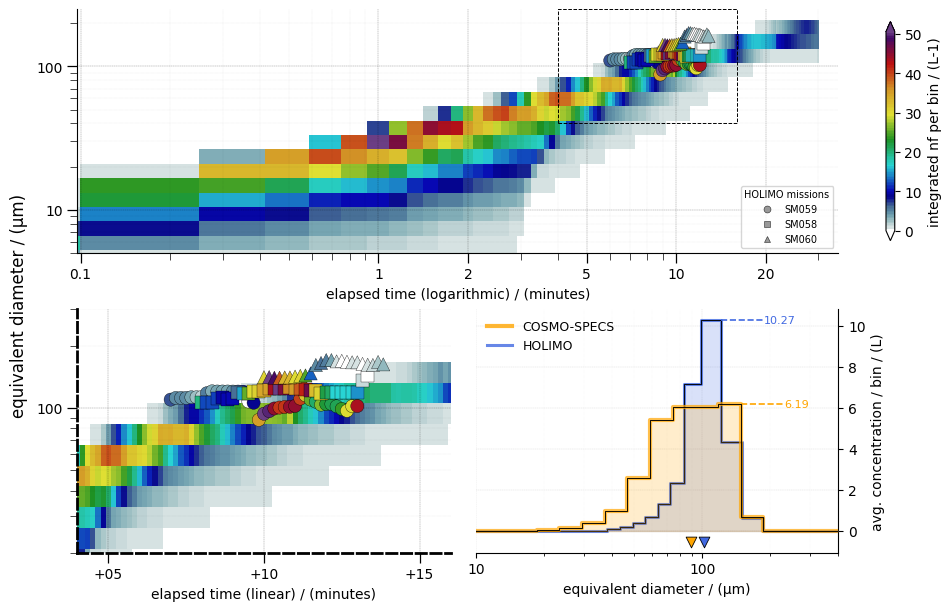

In [120]:
# Updated FoO block: one model line over global HOLIMO elapsed window.
holimo_ice_var = "Ice_Pristine_PSDnoNorm"

holimo_overlay_cfg = {
    "ds_hd10": ds_hd10,
    "obs_ids": obs_ids,
    "time_frames_plume": time_frames_plume,
    "growth_times_min": growth_times_min,
    "seeding_start_times": seeding_start_times,
    "var": holimo_ice_var,
    "threshold": 1e-10,
    "unit_factor": 1e3,
    "scatter_cmap": new_jet3_soft,
    "markers": ["o", "s", "^"],
    "sizes": [90, 90, 90],
    "alpha": 1.0,
    "edgecolor": "black",
    "linewidth": 0.25,
    "legend_loc": "lower right",
    "marker_size_scale": 1.0,
}

xlims = {"symlog": [0, 35], "elapsed": [4, 15]}
ylims = {"symlog": [1, 500], "elapsed": [20, 250]}
abs_xlim = [np.datetime64("2023-01-25T12:29:00"), np.datetime64("2023-01-25T13:04:00")]

# Histogram settings for comparison panel.
HIST_DIAM_BOUNDS = (10.0, 400.0)
absolute_mode = True  # True: absolute time-mean concentration, False: FoO (%)
# HIST_BIN_EDGES = np.array([HIST_DIAM_BOUNDS[0], HIST_DIAM_BOUNDS[1]], dtype=float)


def _diameter_centers_to_log_edges(diameter_centers: np.ndarray) -> np.ndarray:
    centers = np.asarray(diameter_centers, dtype=float)
    centers = np.sort(centers[np.isfinite(centers) & (centers > 0)])
    centers = np.unique(centers)
    if centers.size < 2:
        return np.array([], dtype=float)

    lcent = np.log(centers)
    ledges = np.empty(centers.size + 1, dtype=float)
    ledges[1:-1] = 0.5 * (lcent[:-1] + lcent[1:])
    ledges[0] = lcent[0] - 0.5 * (lcent[1] - lcent[0])
    ledges[-1] = lcent[-1] + 0.5 * (lcent[-1] - lcent[-2])
    return np.exp(ledges)


def _hist_profile_by_diameter(
    da: xr.DataArray,
    threshold: float,
    bin_edges: np.ndarray | None = None,
):
    if "time" not in da.dims or "diameter" not in da.dims:
        return np.array([]), np.array([])
    other_dims = [d for d in da.dims if d not in ("time", "diameter")]
    if other_dims:
        da = da.mean(dim=other_dims, skipna=True)

    diam = np.asarray(da["diameter"].values, dtype=float)
    tvals = np.asarray(da["time"].values)
    vals = np.asarray(da.values, dtype=float)
    if vals.ndim != 2 or vals.shape[1] != diam.size or vals.shape[0] != tvals.size:
        return np.array([]), np.array([])

    if bin_edges is None:
        bin_edges = _diameter_centers_to_log_edges(diam)
    else:
        bin_edges = np.asarray(bin_edges, dtype=float)

    if bin_edges.size < 2 or np.any(~np.isfinite(bin_edges)) or np.any(np.diff(bin_edges) <= 0):
        return np.array([]), np.array([])

    vals = np.where(np.isfinite(vals) & (vals > threshold), vals, 0.0)
    tmin = ((tvals - tvals[0]) / np.timedelta64(1, "m")).astype(float)
    prof = np.trapezoid(vals, x=tmin, axis=0)

    # Re-bin integrated profile on requested log-diameter boundaries.
    hist, _ = np.histogram(diam, bins=bin_edges, weights=prof)
    centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])
    return centers, np.asarray(hist, dtype=float)


def _freq_occurrence_by_diameter(
    da: xr.DataArray,
    threshold: float,
    bin_edges: np.ndarray | None = None,
):
    centers, hist = _hist_profile_by_diameter(da=da, threshold=threshold, bin_edges=bin_edges)
    if centers.size == 0:
        return np.array([]), np.array([])
    total = float(np.nansum(hist))
    if not np.isfinite(total) or total <= 0:
        return centers, np.zeros_like(centers, dtype=float)
    return centers, np.asarray(100.0 * hist / total, dtype=float)

def _select_model_da_for_elapsed_window(da_model_elapsed: xr.DataArray, e_lo: float, e_hi: float) -> xr.DataArray:
    if not np.isfinite(e_lo) or not np.isfinite(e_hi):
        return da_model_elapsed.isel(time=slice(0, 0))
    if e_hi < e_lo:
        e_lo, e_hi = e_hi, e_lo
    return da_model_elapsed.where((da_model_elapsed.time_elapsed >= e_lo) & (da_model_elapsed.time_elapsed <= e_hi), drop=True)


def _select_holimo_da_for_elapsed_window(obs_elapsed_by_id: dict[str, xr.DataArray], obs_id: str, e_lo: float, e_hi: float) -> xr.DataArray:
    da = obs_elapsed_by_id.get(obs_id)
    if da is None:
        return xr.DataArray([], dims=("time",), coords={"time": []})
    if not np.isfinite(e_lo) or not np.isfinite(e_hi):
        return da.isel(time=slice(0, 0))
    if e_hi < e_lo:
        e_lo, e_hi = e_hi, e_lo
    return da.where((da.time_elapsed >= e_lo) & (da.time_elapsed <= e_hi), drop=True)


def _elapsed_duration_minutes(da: xr.DataArray) -> float:
    if "time" not in da.dims or da.sizes.get("time", 0) < 2:
        return 0.0
    tvals = np.asarray(da["time"].values)
    dt = float((tvals[-1] - tvals[0]) / np.timedelta64(1, "m"))
    return max(dt, 0.0)


# Main stacked pcolormesh figure.
fig_stack = plt.figure(figsize=(9.4, 6.0), constrained_layout=True)
gs = fig_stack.add_gridspec(2, 2, width_ratios=[0.5, 0.485], wspace=0.005, hspace=0.01)
ax_main = [fig_stack.add_subplot(gs[0, 0:2]), fig_stack.add_subplot(gs[1, 0])]
ax_hist = fig_stack.add_subplot(gs[1, 1])

panel_specs = [("symlog", xlims["symlog"], [5, 250]), ("elapsed", [4, 16], [40, 250])]
cbar_kwargs={"shrink": 0.9, "aspect":25, "pad": 0.001, "extend":"both"}
pmesh_ref = None
for i, (fmt, xwin, ywin) in enumerate(panel_specs):
    _, axes_plotted, pmesh = plot_plume_path_sum(
        datasets,
        kind="integrated",
        variable="nf",
        xlim=abs_xlim,
        common_xlim_minutes=35,
        ylim=[5, 250],
        zlim=(1, 50),
        cmap=new_jet3_soft,
        log_norm=False,
        x_axis_fmt=fmt,
        add_missing_data=True,
        holimo_overlay=holimo_overlay_cfg,
        axes_override=[ax_main[i]],
        add_colorbar=False,
        add_shared_labels=False,
        annote_letters=False,
        return_pmesh=True,
        cbar_kwargs=cbar_kwargs,
        add_holimo_legend=(i == 0),
    )
    axes_plotted.flat[0].set_xlim(xwin)
    axes_plotted.flat[0].set_ylim(ywin)
    if pmesh_ref is None:
        pmesh_ref = pmesh

x1_lo, x1_hi = panel_specs[1][1]
y1_lo, y1_hi = panel_specs[1][2]
ax_main[0].add_patch(plt.Rectangle((x1_lo, y1_lo), x1_hi - x1_lo, y1_hi - y1_lo, fill=False, edgecolor="black", linestyle="--", linewidth=.70, zorder=300))
ax_main[1].set_title("")

# Remove zero tick from symlog elapsed-time axis.
ax_main[0].set_xticks([t for t in ax_main[0].get_xticks() if not np.isclose(t, 0.0)])

for sp in ax_main[1].spines.values():
    sp.set_color("black")
    sp.set_linestyle("--")
    sp.set_linewidth(2.0)

for ax in ax_main:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
ax_hist.spines["top"].set_visible(False)
ax_hist.spines["left"].set_visible(False)

unit = datasets[next(iter(datasets))]["integrated"]["nf"].attrs.get("units", "-")
cb = fig_stack.colorbar(pmesh_ref, ax=ax_main[0], **cbar_kwargs)
cb.set_label(rf"integrated nf per bin / ({unit})")

# ---- FoO: one model line over global HOLIMO elapsed window ----
run_label = next(k for k, v in datasets.items() if isinstance(v.get("integrated"), xr.Dataset))
obs_threshold = holimo_overlay_cfg["threshold"]
obs_var = holimo_overlay_cfg["var"]
mission_ids = holimo_overlay_cfg["obs_ids"]
mission_frames = holimo_overlay_cfg["time_frames_plume"]
mission_seed_starts = holimo_overlay_cfg["seeding_start_times"]


# Convert datasets to elapsed time OUTSIDE plotting function.
idx_mod_ice_diam_start = 30 # start for sizes of 1µm for bin boundaries of histogram
model_seed_start = np.datetime64("2023-01-25T12:30:00")
da_model_elapsed = _prepare_da(datasets[run_label]["integrated"], "nf", sum_cell=True)
da_model_elapsed = da_model_elapsed.sel(time=slice(abs_xlim[0], abs_xlim[1]))
da_model_elapsed = _assign_elapsed_time(da_model_elapsed, model_seed_start)

diam_mod = np.asarray(da_model_elapsed["diameter"].sel(diameter=slice(*ylims["symlog"])).values, dtype=float)
diam_obs = np.asarray(ds_hd10[obs_var]["diameter"].sel(diameter=slice(*ylims["symlog"])).values, dtype=float)

bin_edges_mod = _diameter_centers_to_log_edges(diam_mod)
bin_edges_obs = _diameter_centers_to_log_edges(diam_obs)

print(f"diam_mod ({diam_mod.size}): {diam_mod}")
print(f"diam_obs ({diam_obs.size}): {diam_obs}")
if bin_edges_mod.size >= 2:
    print(
        f"FoO binning check :: model nbins={bin_edges_mod.size - 1}, "
        f"range=[{bin_edges_mod[0]:.3f}, {bin_edges_mod[-1]:.3f}]"
    )
else:
    print("FoO binning check :: model has insufficient diameter points for log bins")
if bin_edges_obs.size >= 2:
    print(
        f"FoO binning check :: obs   nbins={bin_edges_obs.size - 1}, "
        f"range=[{bin_edges_obs[0]:.3f}, {bin_edges_obs[-1]:.3f}]"
    )
else:
    print("FoO binning check :: obs has insufficient diameter points for log bins")

obs_elapsed_by_id: dict[str, xr.DataArray] = {}
elapsed_windows = []
for i_mis, (obs_id, (t_lo, t_hi)) in enumerate(zip(mission_ids, mission_frames)):
    seed_t = np.datetime64(mission_seed_starts[i_mis])
    e_lo = float((np.datetime64(t_lo) - seed_t) / np.timedelta64(1, "m"))
    e_hi = float((np.datetime64(t_hi) - seed_t) / np.timedelta64(1, "m"))
    elapsed_windows.append((min(e_lo, e_hi), max(e_lo, e_hi)))

    if obs_var in ds_hd10:
        da_obs_i = ds_hd10[obs_var].sel(time=slice(t_lo, t_hi)) * holimo_overlay_cfg["unit_factor"]
        if da_obs_i.sizes.get("time", 0) > 0:
            obs_elapsed_by_id[obs_id] = _assign_elapsed_time(da_obs_i, seed_t)

# Global HOLIMO elapsed window envelope for ONE model line.
e_lo_global = min(w[0] for w in elapsed_windows)
e_hi_global = max(w[1] for w in elapsed_windows)
da_model = _select_model_da_for_elapsed_window(da_model_elapsed, e_lo_global, e_hi_global)
if absolute_mode:
    d_model, hist_model = _hist_profile_by_diameter(da_model, bin_edges=bin_edges_mod, threshold=0.0)
    dur_model = _elapsed_duration_minutes(da_model)
    f_model = hist_model / dur_model if dur_model > 0 else np.array([])
else:
    d_model, f_model = _freq_occurrence_by_diameter(da_model, bin_edges=bin_edges_mod, threshold=0.0)

if d_model.size and np.isfinite(f_model).any():
    ax_hist.fill_between(
        d_model,
        f_model,
        step="pre",
        color="orange",
        alpha=0.20,
        zorder=13,
    )
    ax_hist.step(
        d_model,
        f_model,
        color="orange",
        lw=3.0,
        linestyle="-",
        label="COSMO-SPECS",
        alpha=0.7,
        zorder=14,
    )
    ax_hist.step(
        d_model,
        f_model,
        color="black",
        lw=0.7,
        linestyle="-",
        alpha=0.95,
        zorder=15,
    )

# Combined HOLIMO histogram across all seeding missions.
hist_obs_sum = None
d_obs_ref = np.array([])
dur_obs_sum = 0.0
for i_mis, (obs_id, (t_lo, t_hi)) in enumerate(zip(mission_ids, mission_frames)):
    seed_t = np.datetime64(mission_seed_starts[i_mis])
    e_lo = float((np.datetime64(t_lo) - seed_t) / np.timedelta64(1, "m"))
    e_hi = float((np.datetime64(t_hi) - seed_t) / np.timedelta64(1, "m"))

    da_obs = _select_holimo_da_for_elapsed_window(obs_elapsed_by_id, obs_id, e_lo, e_hi)
    d_obs_i, hist_obs_i = _hist_profile_by_diameter(da_obs, bin_edges=bin_edges_obs, threshold=obs_threshold)
    if d_obs_i.size and not np.isfinite(hist_obs_i).any():
        d_obs_i, hist_obs_i = _hist_profile_by_diameter(da_obs, bin_edges=bin_edges_obs, threshold=0.0)

    if d_obs_i.size and np.isfinite(hist_obs_i).any():
        if hist_obs_sum is None:
            d_obs_ref = d_obs_i
            hist_obs_sum = np.array(hist_obs_i, dtype=float)
        elif hist_obs_sum.shape == hist_obs_i.shape:
            hist_obs_sum += np.asarray(hist_obs_i, dtype=float)
        dur_obs_sum += _elapsed_duration_minutes(da_obs)

if hist_obs_sum is not None and np.isfinite(hist_obs_sum).any():
    if absolute_mode:
        f_obs_all = hist_obs_sum / dur_obs_sum if dur_obs_sum > 0 else np.array([])
    else:
        total_obs = float(np.nansum(hist_obs_sum))
        f_obs_all = np.asarray(100.0 * hist_obs_sum / total_obs, dtype=float) if np.isfinite(total_obs) and total_obs > 0 else np.array([])

    if f_obs_all.size and np.isfinite(f_obs_all).any():
        ax_hist.fill_between(
            d_obs_ref,
            f_obs_all,
            step="pre",
            color="royalblue",
            alpha=0.2,
            zorder=5,
            label="_nolegend_",
        )
        ax_hist.step(
            d_obs_ref,
            f_obs_all,
            color="royalblue",
            lw=2.2,
            linestyle="-",
            alpha=0.8,
            zorder=6,
            label="HOLIMO",
        )
        ax_hist.step(
            d_obs_ref,
            f_obs_all,
            color="black",
            lw=0.7,
            linestyle="-",
            alpha=0.95,
            zorder=7,
        )

ax_hist.set_xscale("log")
ax_hist.set_xlim(HIST_DIAM_BOUNDS)
ax_hist.grid(True, which="major", linestyle="--", linewidth=0.25, alpha=0.6)
ax_hist.grid(True, which="minor", linestyle=":", linewidth=0.15, alpha=0.35)
ax_hist.set_ylabel("avg. concentration / bin / (L)")
ax_hist.set_xlabel("equivalent diameter / (µm)")
ax_hist.yaxis.tick_right()
ax_hist.yaxis.set_label_position("right")
ax_hist.xaxis.set_major_formatter(plt.FuncFormatter(
            lambda x, p: f'{x:.3f}'.rstrip('0').rstrip('.') if x < 1 else f'{x:.0f}'))


# Short dashed line at max FoO/concentration with value annotation (to the right of peak).
x_min_lim, x_max_lim = HIST_DIAM_BOUNDS[0], HIST_DIAM_BOUNDS[1]
log_span = np.log(x_max_lim) - np.log(x_min_lim)
seg_frac = 0.12
if d_model.size and np.isfinite(f_model).any():
    imax = int(np.nanargmax(f_model))
    d_peak_mod = float(d_model[imax])
    y_max_mod = float(f_model[imax])
    d_end_mod = np.exp(np.log(d_peak_mod) + seg_frac * log_span)
    d_end_mod = min(d_end_mod, x_max_lim * 0.98)
    ax_hist.hlines(y_max_mod, d_peak_mod, d_end_mod, colors="orange", linestyles="--", lw=1.2, zorder=8)
    ax_hist.annotate(f"{y_max_mod:.2f}", xy=(d_end_mod, y_max_mod), ha="left", va="center", fontsize=8, color="orange")
if 'd_obs_ref' in locals() and d_obs_ref.size and np.isfinite(f_obs_all).any():
    imax_o = int(np.nanargmax(f_obs_all))
    d_peak_obs = float(d_obs_ref[imax_o])
    y_max_obs = float(f_obs_all[imax_o])
    d_end_obs = np.exp(np.log(d_peak_obs) + seg_frac * log_span)
    d_end_obs = min(d_end_obs, x_max_lim * 0.98)
    ax_hist.hlines(y_max_obs, d_peak_obs, d_end_obs, colors="royalblue", linestyles="--", lw=1.2, zorder=8)
    ax_hist.annotate(f"{y_max_obs:.2f}", xy=(d_end_obs, y_max_obs), ha="left", va="center", fontsize=8, color="royalblue")

# Median diameter of FoO/concentration distribution on x-axis (triangle-up, line-colored).
ylim_hist = ax_hist.get_ylim()
y_axis_bottom = ylim_hist[0]
if d_model.size and np.isfinite(f_model).any():
    cdf_mod = np.nancumsum(np.asarray(f_model, dtype=float))
    tot_mod = cdf_mod[-1]
    if np.isfinite(tot_mod) and tot_mod > 0:
        cdf_n = cdf_mod / tot_mod
        med_d_mod = np.interp(0.5, cdf_n, d_model)
        ax_hist.scatter(med_d_mod, y_axis_bottom, marker="v", s=60, color="orange", edgecolors="black", linewidths=0.6, zorder=10, clip_on=True)
if "d_obs_ref" in locals() and d_obs_ref.size and np.isfinite(f_obs_all).any():
    cdf_obs = np.nancumsum(np.asarray(f_obs_all, dtype=float))
    tot_obs = cdf_obs[-1]
    if np.isfinite(tot_obs) and tot_obs > 0:
        cdf_n = cdf_obs / tot_obs
        med_d_obs = np.interp(0.5, cdf_n, d_obs_ref)
        ax_hist.scatter(med_d_obs, y_axis_bottom, marker="v", s=60, color="royalblue", edgecolors="black", linewidths=0.6, zorder=10, clip_on=True)

# Histogram legend (names only; max values shown on dashed lines).
legend_handles, legend_labels = [], []
if 'f_model' in locals() and hasattr(f_model, 'size') and f_model.size and np.isfinite(f_model).any():
    legend_handles.append(Line2D([], [], color="orange", lw=3.0, linestyle="-", alpha=0.8))
    legend_labels.append("COSMO-SPECS")
if 'f_obs_all' in locals() and f_obs_all.size and np.isfinite(f_obs_all).any():
    legend_handles.append(Line2D([], [], color="royalblue", lw=2.2, linestyle="-", alpha=0.8))
    legend_labels.append("HOLIMO")
if legend_handles:
    ax_hist.legend(legend_handles, legend_labels, loc="upper left", frameon=False, fontsize=9)
ax_main[0].set_title("")
ax_main[0].set_xlabel("elapsed time (logarithmic) / (minutes)")
ax_main[1].set_xlabel("elapsed time (linear) / (minutes)")
ax_main[-1].set_ylim(20, 300)
ax_main[-1].yaxis.set_major_formatter(plt.FuncFormatter(
            lambda x, p: f'{x:.3f}'.rstrip('0').rstrip('.') if x < 1 else f'{x:.0f}'))

fig_stack.supylabel("equivalent diameter / (µm)")
# fig_stack.text(0.005, 0.5, "equivalent diameter / (µm)", va="center", rotation="vertical")
# ax_main[0].text(
#     xlims["symlog"][0] + 0.13,
#     -0.075,
#     "elapsed time (log minutes from ignition)",
#     transform=ax_main[0].get_xaxis_transform(),
#     ha="left",
#     va="top",
# )

fig_stack.savefig("output/figure11_plume_path_plot_clean_symlog_with_zoom_panel_hist.png", dpi=500, bbox_inches="tight")

***Figure 11.** Time-diameter evolution along tracked plume paths after seeding. Background colors show modeled per-bin number concentration (log-scaled) as a function of elapsed time and equivalent diameter, aggregated over tracked plume cells for each run. The x-axis uses a symlog transform to resolve the first minute after ignition while retaining the full growth period. HOLIMO observations are overlaid as mission-specific scatter points at mean diameter, with marker shape distinguishing seeding missions and marker color mapped to observed concentration on the same color scale as the model field.*